In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('state_crime.csv')

In [3]:
data.head()

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    51 non-null     str    
 1   violent                  51 non-null     float64
 2   murder                   51 non-null     float64
 3   hs_grad                  51 non-null     float64
 4   poverty                  51 non-null     float64
 5   single                   51 non-null     float64
 6   white                    51 non-null     float64
 7   urban                    51 non-null     float64
 8   graduation_gap           51 non-null     float64
 9   social_stress_index      51 non-null     float64
 10  urban_stress_index       51 non-null     float64
 11  violent_to_murder_ratio  51 non-null     float64
dtypes: float64(11), str(1)
memory usage: 4.9 KB


In [5]:
# Imports + configuration

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # Quick EDA audit table: types, missingness, uniqueness.

    return (
        pd.DataFrame(
            {
                "dtype": df.dtypes.astype(str),
                "n_missing": df.isna().sum(),
                "missing_%": (df.isna().mean() * 100).round(2),
                "n_unique": df.nunique(dropna=False),
            }
        )
        .sort_values(["missing_%", "n_unique"], ascending=[False, True])
    )


def clip_quantiles(df: pd.DataFrame, cols: list[str], q_low: float = 0.01, q_high: float = 0.99) -> pd.DataFrame:
    # Winsorize/clip numeric columns to reduce extreme outlier influence on distances.

    out = df.copy()
    for c in cols:
        lo, hi = out[c].quantile([q_low, q_high])
        out[c] = out[c].clip(lo, hi)
    return out


def evaluate_clustering(X: np.ndarray, labels: np.ndarray) -> dict:
    # Compute a consistent metric bundle for clustering comparison.
    #
    # Why these metrics?
    # ------------------
    # 1) Silhouette (higher is better)
    #    - For each point i:
    #        a(i) = average distance from i to points in its own cluster
    #        b(i) = lowest average distance from i to points in any other cluster
    #      silhouette(i) = (b(i) - a(i)) / max(a(i), b(i))
    #    - Intuition: points should be close to their own cluster and far from others.
    #
    # 2) Davies–Bouldin index (lower is better)
    #    - For each cluster, compute how "wide" it is (scatter).
    #    - Compare that to distance between cluster centers.
    #    - Intuition: overlap/ambiguity between clusters should be low.
    #
    # 3) Calinski–Harabasz score (higher is better)
    #    - Ratio: (between-cluster dispersion) / (within-cluster dispersion)
    #    - Intuition: clusters should be far apart and internally tight.
    #
    # Important: these are *internal* metrics (no ground truth). Use them as guides,
    # then validate with interpretability.

    # If all labels are same, silhouette/CH are undefined
    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    }


In [6]:
raw = pd.read_csv("state_crime.csv")



In [7]:
raw.head()

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


In [8]:
raw.describe()

,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,411.482353,4.900000,86.878431,13.854902,25.186275,77.968627,60.670196,13.121569,39.041176,8.282031,74.401180
std,208.017447,3.646094,3.377769,3.110583,4.786565,13.553029,20.802432,3.377769,6.875760,3.078181,22.516655
min,119.900000,0.900000,79.900000,8.500000,17.900000,26.900000,17.380000,8.200000,28.000000,1.981320,38.822785
25%,263.350000,2.650000,84.050000,11.500000,22.100000,70.600000,46.565000,10.200000,34.500000,6.668860,60.224479
50%,366.400000,4.700000,87.400000,14.200000,25.500000,80.000000,59.170000,12.600000,38.400000,8.513750,72.138889
75%,507.400000,6.150000,89.800000,16.400000,27.300000,87.750000,78.415000,15.950000,42.400000,9.921030,86.482857
max,1348.900000,24.200000,91.800000,21.900000,48.000000,95.800000,100.000000,20.100000,66.400000,18.400000,150.619048


In [9]:
# Small cleanup driven by EDA:
# Some state names have trailing spaces (e.g., 'Kansas '), which can cause messy reporting.
raw["state"] = raw["state"].astype(str).str.strip()

display(raw.head())
print("Dataset shape:", raw.shape)

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


Dataset shape: (51, 12)


In [ ]:
audit = audit_dataframe(raw)
display(audit)

print("Duplicate states:", raw["state"].duplicated().sum())

In [ ]:
# Small cleanup driven by EDA:
# Some state names have trailing spaces (e.g., 'Kansas '), which can cause messy reporting.
raw["state"] = raw["state"].astype(str).str.strip()

display(raw.head())
print("Dataset shape:", raw.shape)

In [10]:
audit = audit_dataframe(raw)
display(audit)

print("Duplicate states:", raw["state"].duplicated().sum())

,dtype,n_missing,missing_%,n_unique
murder,float64,0,0.0,38
poverty,float64,0,0.0,40
single,float64,0,0.0,41
hs_grad,float64,0,0.0,42
graduation_gap,float64,0,0.0,42
social_stress_index,float64,0,0.0,46
white,float64,0,0.0,47
state,str,0,0.0,51
violent,float64,0,0.0,51
urban,float64,0,0.0,51


Duplicate states: 0


,count,mean,std,min,25%,50%,75%,max
violent,51.0,411.482353,208.017447,119.900000,263.350000,366.400000,507.400000,1348.900000
murder,51.0,4.900000,3.646094,0.900000,2.650000,4.700000,6.150000,24.200000
hs_grad,51.0,86.878431,3.377769,79.900000,84.050000,87.400000,89.800000,91.800000
poverty,51.0,13.854902,3.110583,8.500000,11.500000,14.200000,16.400000,21.900000
single,51.0,25.186275,4.786565,17.900000,22.100000,25.500000,27.300000,48.000000
white,51.0,77.968627,13.553029,26.900000,70.600000,80.000000,87.750000,95.800000
urban,51.0,60.670196,20.802432,17.380000,46.565000,59.170000,78.415000,100.000000
graduation_gap,51.0,13.121569,3.377769,8.200000,10.200000,12.600000,15.950000,20.100000
social_stress_index,51.0,39.041176,6.875760,28.000000,34.500000,38.400000,42.400000,66.400000
urban_stress_index,51.0,8.282031,3.078181,1.981320,6.668860,8.513750,9.921030,18.400000


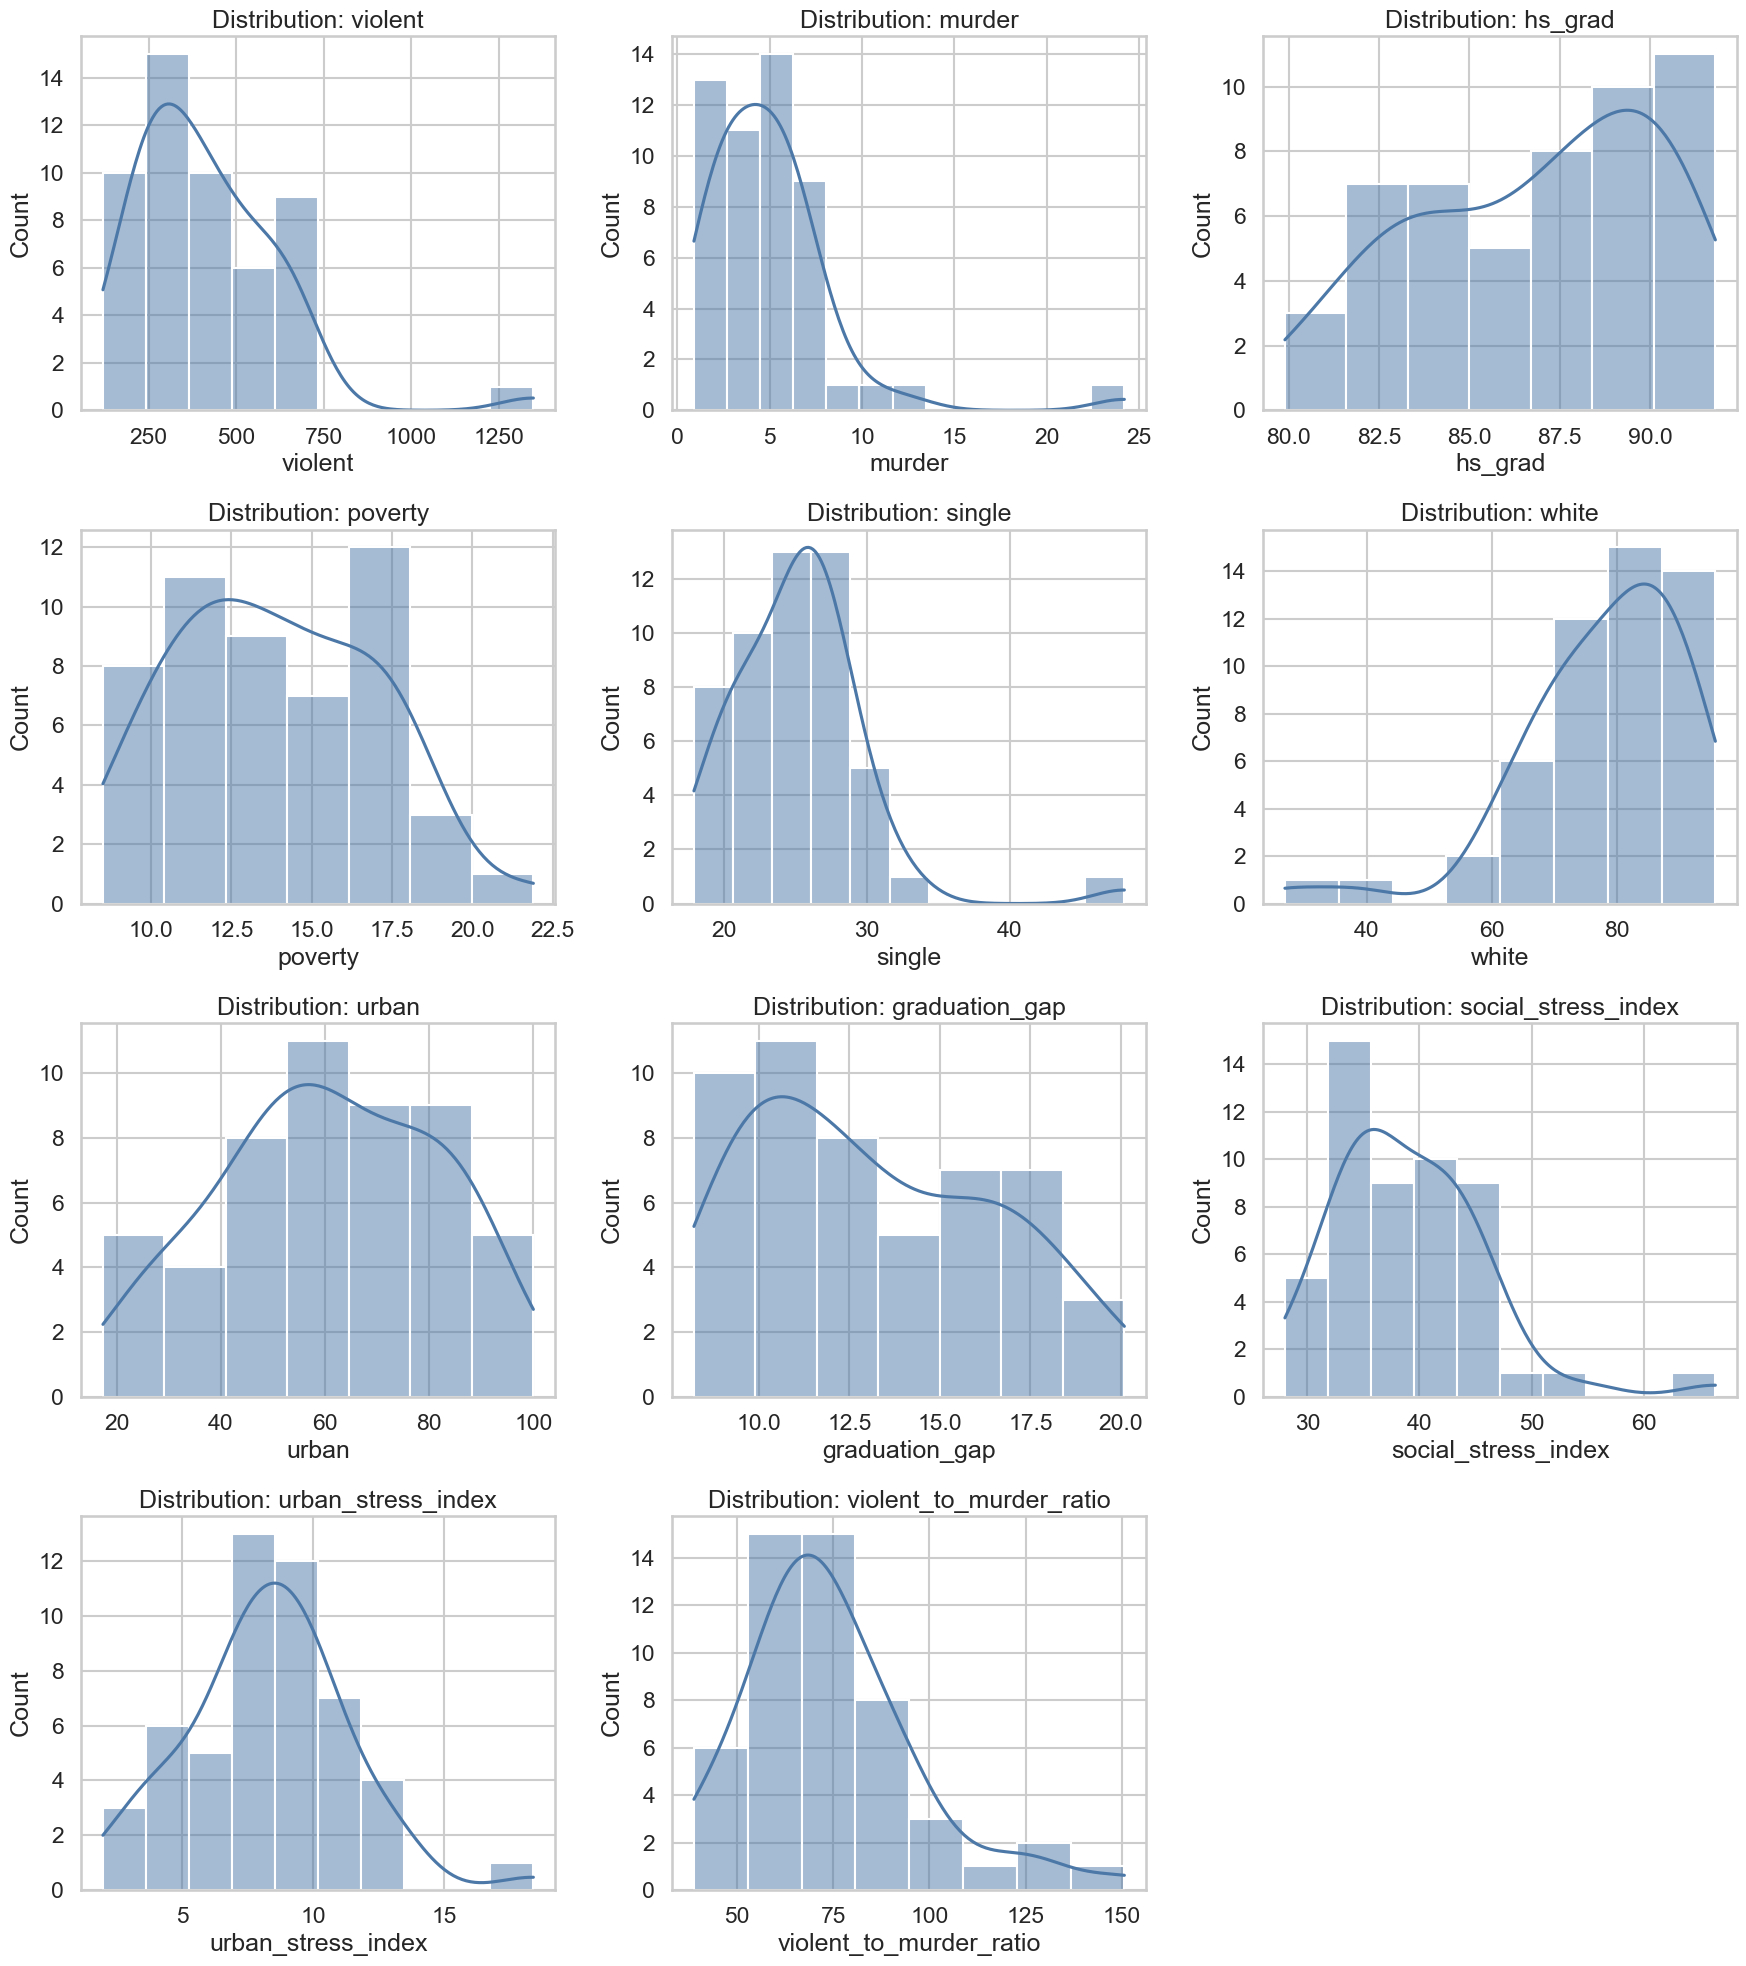

In [11]:
# Numeric columns (excluding the ID-like 'state')
num_cols = raw.columns.drop("state").tolist()

display(raw[num_cols].describe().T)

# Histograms
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.histplot(raw[c], kde=True, ax=axes[i], color="#4C78A8")
    axes[i].set_title(f"Distribution: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Boxplots to visualize outliers
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.boxplot(y=raw[c], ax=axes[i], color="#F58518")
    axes[i].set_title(f"Outliers: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()